# Visualize the transformed training dataset

This notebook uses the same `create_training_dataloaders` function as `Experiment.adapt()`. The displayed pixels are read directly from the materialized `TensorDataset` backing the selected dataloader, so no visualization-only transformation, normalization, or reconstruction is applied.

On the first run, the transformed train and validation sets are created and cached. Later runs load those exact tensors from disk.

In [1]:
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset


def find_repo_root(start):
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Could not find the repository root.")


REPO_ROOT = find_repo_root(Path.cwd())
SOURCE_DIR = REPO_ROOT / "src"
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

from domain_knowledge_analysis import utils

print(f"Repository: {REPO_ROOT}")

Repository: /Users/gianmarcoalbano/domain-knowledge-analysis-generative-models


## Settings

Keep `TRANSFORMATION_OVERRIDE = None` to inspect exactly the transformation configured for adaptation in the YAML file. To explore another implemented transformation or intensity without editing YAML, provide a dictionary such as `{'type': 'rotation', 'intensity': 30.0}`. An override affects this notebook only.

In [2]:
CONFIG_PATH = REPO_ROOT / "config" / "vae_mnist.yaml"

# None follows the YAML used by Experiment.adapt().
TRANSFORMATION_OVERRIDE = None
# Example exploration override:
# TRANSFORMATION_OVERRIDE = {"type": "rotation", "intensity": 30.0}

SPLIT = "train"  # "train" or "validation"
NUMBER_OF_SAMPLES = 16
SAMPLE_SEED = 0
SAMPLE_INDICES = None  # Example: [0, 10, 25, 100]; takes precedence over random sampling.

In [8]:
config = utils.load_config(CONFIG_PATH)
lora_config = config.get("lora")
if not lora_config or not lora_config.get("dataset_transformation"):
    raise ValueError(
        f"No lora.dataset_transformation is configured in {CONFIG_PATH}."
    )

configured_transformation = lora_config["dataset_transformation"]
transformation_config = (
    configured_transformation
    if TRANSFORMATION_OVERRIDE is None
    else TRANSFORMATION_OVERRIDE
)

if TRANSFORMATION_OVERRIDE is not None:
    print(
        "NOTE: This notebook is using an override. Put the same values under "
        "lora.dataset_transformation in the YAML before training if you want "
        "Experiment.adapt() to use this exact transformed dataset."
    )

print(f"Config: {CONFIG_PATH}")
print(f"Source dataset: {config['dataset']['name']}")
print(f"Transformation: {transformation_config}")
print("Creating or loading the exact cached adaptation datasets...")

train_dataloader, validation_dataloader = utils.create_training_dataloaders(
    config=config,
    transformation_config=transformation_config,
)

split = SPLIT.lower()
if split == "train":
    selected_dataloader = train_dataloader
elif split == "validation":
    selected_dataloader = validation_dataloader
else:
    raise ValueError("SPLIT must be 'train' or 'validation'.")

selected_dataset = selected_dataloader.dataset
if not isinstance(selected_dataset, TensorDataset):
    raise TypeError(
        "Expected the transformed cache to be a TensorDataset. This guard prevents "
        "the notebook from silently applying a different display pipeline."
    )

training_images, training_labels = selected_dataset.tensors
print(f"Selected split: {split} ({len(selected_dataset)} samples)")
print(f"Stored image tensor: shape={tuple(training_images.shape)}, dtype={training_images.dtype}")
print("The grid below reads directly from this stored tensor.")
print(len(train_dataloader.dataset), "training samples")

Config: /Users/gianmarcoalbano/domain-knowledge-analysis-generative-models/config/vae_mnist.yaml
Source dataset: mnist
Transformation: {'type': 'rotation', 'intensity': 45.0}
Creating or loading the exact cached adaptation datasets...
Selected split: train (48000 samples)
Stored image tensor: shape=(48000, 1, 28, 28), dtype=torch.float32
The grid below reads directly from this stored tensor.
48000 training samples


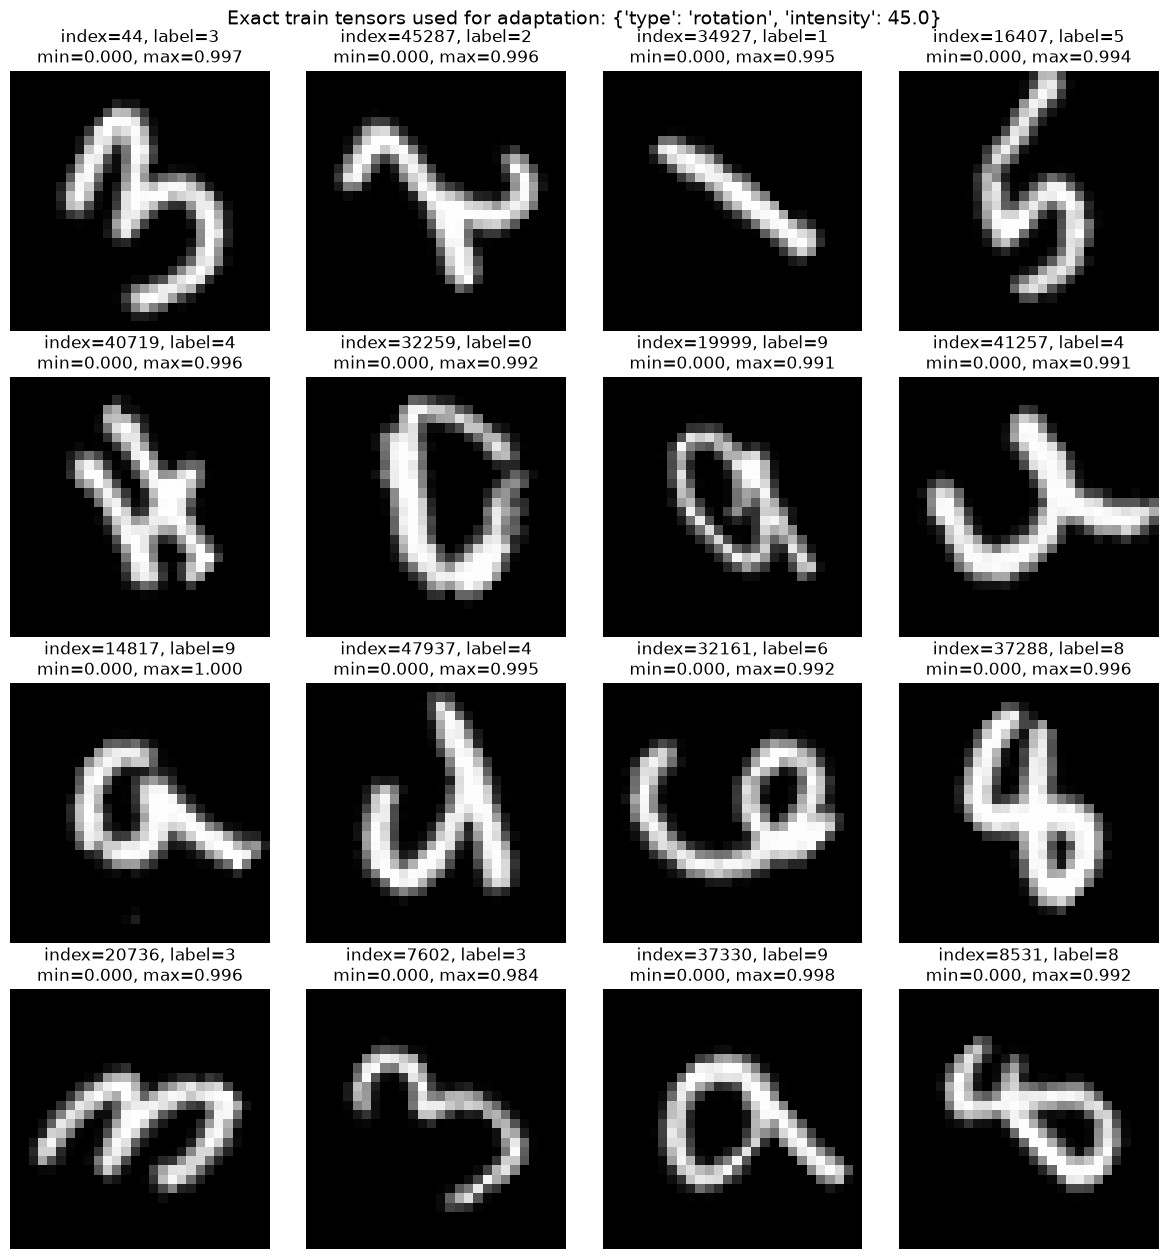

In [4]:
def select_sample_indices(dataset_size, requested_indices, number_of_samples, seed):
    if requested_indices is not None:
        indices = [int(index) for index in requested_indices]
        invalid = [index for index in indices if index < 0 or index >= dataset_size]
        if invalid:
            raise IndexError(f"Sample indices outside [0, {dataset_size - 1}]: {invalid}")
        return indices

    sample_count = min(int(number_of_samples), dataset_size)
    generator = torch.Generator().manual_seed(int(seed))
    return torch.randperm(dataset_size, generator=generator)[:sample_count].tolist()


def format_label(label):
    label = label.detach().cpu()
    if label.numel() == 1:
        return str(label.item())
    return str(label.tolist())


def plot_stored_training_samples(images, labels, indices, columns=4):
    if not indices:
        raise ValueError("At least one sample index is required.")

    columns = min(columns, len(indices))
    rows = math.ceil(len(indices) / columns)
    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(3.0 * columns, 3.2 * rows),
        squeeze=False,
    )

    for axis, index in zip(axes.flat, indices):
        image = images[index].detach().cpu()
        label = labels[index]

        if image.ndim != 3:
            raise ValueError(f"Expected a C x H x W image, got shape {tuple(image.shape)}.")

        if image.shape[0] == 1:
            axis.imshow(
                image[0].numpy(),
                cmap="gray",
                vmin=0.0,
                vmax=1.0,
                interpolation="nearest",
            )
        elif image.shape[0] in (3, 4):
            axis.imshow(
                image.permute(1, 2, 0).numpy(),
                interpolation="nearest",
            )
        else:
            raise ValueError(
                f"Cannot directly display an image with {image.shape[0]} channels."
            )

        axis.set_title(
            f"index={index}, label={format_label(label)}\n"
            f"min={image.min().item():.3f}, max={image.max().item():.3f}"
        )
        axis.axis("off")

    for axis in axes.flat[len(indices):]:
        axis.axis("off")

    figure.suptitle(
        f"Exact {split} tensors used for adaptation: {transformation_config}",
        fontsize=14,
    )
    figure.tight_layout()
    plt.show()


indices = select_sample_indices(
    dataset_size=len(selected_dataset),
    requested_indices=SAMPLE_INDICES,
    number_of_samples=NUMBER_OF_SAMPLES,
    seed=SAMPLE_SEED,
)
plot_stored_training_samples(
    images=training_images,
    labels=training_labels,
    indices=indices,
)

## Exact-value inspection

Use this cell when you want to inspect the precise stored tensor and label for one displayed sample. The same tensor object is indexed by the adaptation dataloader during training.

In [5]:
inspection_index = indices[0]
exact_image_tensor = training_images[inspection_index]
exact_label_tensor = training_labels[inspection_index]

print(f"Index: {inspection_index}")
print(f"Label: {format_label(exact_label_tensor)}")
print(f"Shape: {tuple(exact_image_tensor.shape)}")
print(f"Dtype: {exact_image_tensor.dtype}")
print(f"Value range: [{exact_image_tensor.min().item()}, {exact_image_tensor.max().item()}]")
exact_image_tensor

Index: 44
Label: 3
Shape: (1, 28, 28)
Dtype: torch.float32
Value range: [0.0, 0.996811032295227]


tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+